## Step 1: Imports
Import all required libraries for data manipulation, visualization, and mapping.

In [47]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

### Load the Dataset
The dataset `Unicorn_Companies.csv` contains information about unicorn companies worldwide, including their industry, valuation, city, country, and the date they joined the unicorn list.

In [48]:
# Load the dataset
df_companies = pd.read_csv("Unicorn_Companies.csv")

# Quick look at the data
df_companies.head()

,Company,Valuation,Date Joined,Industry,City,Country,Continent,Year Founded,Funding,Select Investors
0,Bytedance,$180B,2017-04-07,Artificial intelligence,Beijing,China,Asia,2012,$8B,"Sequoia Capital China, SIG Asia Investments, S..."
1,SpaceX,$100B,2012-12-01,Other,Hawthorne,United States,North America,2002,$7B,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
2,SHEIN,$100B,2018-07-03,E-commerce & direct-to-consumer,Shenzhen,China,Asia,2008,$2B,"Tiger Global Management, Sequoia Capital China..."
3,Stripe,$95B,2014-01-23,Fintech,San Francisco,United States,North America,2010,$2B,"Khosla Ventures, LowercaseCapital, capitalG"
4,Klarna,$46B,2011-12-12,Fintech,Stockholm,Sweden,Europe,2005,$4B,"Institutional Venture Partners, Sequoia Capita..."


## Step 2: Data Exploration
Explore the dataset structure, data types, and statistical properties to understand what we're working with before handling missing values.

In [49]:
# Display the first 10 rows
df_companies.head(10)

,Company,Valuation,Date Joined,Industry,City,Country,Continent,Year Founded,Funding,Select Investors
0,Bytedance,$180B,2017-04-07,Artificial intelligence,Beijing,China,Asia,2012,$8B,"Sequoia Capital China, SIG Asia Investments, S..."
1,SpaceX,$100B,2012-12-01,Other,Hawthorne,United States,North America,2002,$7B,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
2,SHEIN,$100B,2018-07-03,E-commerce & direct-to-consumer,Shenzhen,China,Asia,2008,$2B,"Tiger Global Management, Sequoia Capital China..."
3,Stripe,$95B,2014-01-23,Fintech,San Francisco,United States,North America,2010,$2B,"Khosla Ventures, LowercaseCapital, capitalG"
4,Klarna,$46B,2011-12-12,Fintech,Stockholm,Sweden,Europe,2005,$4B,"Institutional Venture Partners, Sequoia Capita..."
5,Canva,$40B,2018-01-08,Internet software & services,Surry Hills,Australia,Oceania,2012,$572M,"Sequoia Capital China, Blackbird Ventures, Mat..."
6,Checkout.com,$40B,2019-05-02,Fintech,London,United Kingdom,Europe,2012,$2B,"Tiger Global Management, Insight Partners, DST..."
7,Instacart,$39B,2014-12-30,"Supply chain, logistics, & delivery",San Francisco,United States,North America,2012,$3B,"Khosla Ventures, Kleiner Perkins Caufield & By..."
8,JUUL Labs,$38B,2017-12-20,Consumer & retail,San Francisco,United States,North America,2015,$14B,Tiger Global Management
9,Databricks,$38B,2019-02-05,Data management & analytics,San Francisco,United States,North America,2013,$3B,"Andreessen Horowitz, New Enterprise Associates..."


### Shape of the Dataset
Check how many rows and columns the dataset has.

In [50]:
# Get the shape of the dataset
df_companies.shape
# Expected output: (1074, 10)

(1074, 10)

### Data Types and Non-Null Values
Use `info()` to see column names, data types, and how many non-null values each column has.

In [51]:
# Get data types and non-null counts
df_companies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1074 entries, 0 to 1073
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Company           1074 non-null   object
 1   Valuation         1074 non-null   object
 2   Date Joined       1074 non-null   object
 3   Industry          1074 non-null   object
 4   City              1058 non-null   object
 5   Country           1074 non-null   object
 6   Continent         1074 non-null   object
 7   Year Founded      1074 non-null   int64 
 8   Funding           1074 non-null   object
 9   Select Investors  1073 non-null   object
dtypes: int64(1), object(9)
memory usage: 84.0+ KB


### Descriptive Statistics
Get summary statistics (mean, std, min, max) for numerical columns.

In [52]:
# Get descriptive statistics
df_companies.describe()

,Year Founded
count,1074.000000
mean,2012.895717
std,5.698573
min,1919.000000
25%,2011.000000
50%,2014.000000
75%,2016.000000
max,2021.000000


## Data Preprocessing
Before answering the investor's questions, we need to:
1. Extract the **year** each company became a unicorn
2. Convert the **Valuation** column from a string (e.g., `$4B`) to a numeric value

In [53]:
# Create a new column "Year Joined" from "Date Joined"
df_companies['Year Joined'] = pd.to_datetime(df_companies['Date Joined']).dt.year

# Verify
df_companies[['Date Joined', 'Year Joined']].head()

,Date Joined,Year Joined
0,2017-04-07,2017
1,2012-12-01,2012
2,2018-07-03,2018
3,2014-01-23,2014
4,2011-12-12,2011


### Convert `Valuation` to Numeric
The `Valuation` column is stored as a string like `$4B`. We need to convert it to a number so we can perform mathematical operations.

We'll define a function `str_to_num()` that:
- Takes a string like `'$4B'`
- Returns an integer like `4`

In [54]:
# Define the str_to_num() function
def str_to_num(x):
    """
    Convert a string like '$4B' to an integer 4.
    """
    return int(x.strip('$B'))

In [55]:
# Apply the function to the Valuation column
df_companies['valuation_num'] = df_companies['Valuation'].apply(str_to_num)

# Verify
df_companies[['Valuation', 'valuation_num']].head()

,Valuation,valuation_num
0,$180B,180
1,$100B,100
2,$100B,100
3,$95B,95
4,$46B,46


### Find Missing Values
Check how many missing values exist in each column.

In [56]:
# Count missing values per column
df_companies.isnull().sum()

Company              0
Valuation            0
Date Joined          0
Industry             0
City                16
Country              0
Continent            0
Year Founded         0
Funding              0
Select Investors     1
Year Joined          0
valuation_num        0
dtype: int64

### Review Rows with Missing Values
Before deciding how to handle missing values, we need to **see** them in context.

We'll:
1. Create a Boolean mask using `isna()`
2. Use `any(axis=1)` to find rows with at least one missing value
3. Filter the dataframe to show only those rows

In [57]:
# 1. Apply isna() to create a Boolean dataframe
mask = df_companies.isna()

# 2. Apply any() to get a Boolean Series (True if row has any NaN)
mask = mask.any(axis=1)

# 3. Apply the mask to filter rows with missing values
df_missing_rows = df_companies[mask]

# Display the rows with missing values
df_missing_rows

,Company,Valuation,Date Joined,Industry,City,Country,Continent,Year Founded,Funding,Select Investors,Year Joined,valuation_num
12,FTX,$32B,2021-07-20,Fintech,NaN,Bahamas,North America,2018,$2B,"Sequoia Capital, Thoma Bravo, Softbank",2021,32
170,HyalRoute,$4B,2020-05-26,Mobile & telecommunications,NaN,Singapore,Asia,2015,$263M,Kuang-Chi,2020,4
242,Moglix,$3B,2021-05-17,E-commerce & direct-to-consumer,NaN,Singapore,Asia,2015,$471M,"Jungle Ventures, Accel, Venture Highway",2021,3
251,Trax,$3B,2019-07-22,Artificial intelligence,NaN,Singapore,Asia,2010,$1B,"Hopu Investment Management, Boyu Capital, DC T...",2019,3
325,Amber Group,$3B,2021-06-21,Fintech,NaN,Hong Kong,Asia,2015,$328M,"Tiger Global Management, Tiger Brokers, DCM Ve...",2021,3
382,Ninja Van,$2B,2021-09-27,"Supply chain, logistics, & delivery",NaN,Singapore,Asia,2014,$975M,"B Capital Group, Monk's Hill Ventures, Dynamic...",2021,2
541,Advance Intelligence Group,$2B,2021-09-23,Artificial intelligence,NaN,Singapore,Asia,2016,$536M,"Vision Plus Capital, GSR Ventures, ZhenFund",2021,2
629,LinkSure Network,$1B,2015-01-01,Mobile & telecommunications,Shanghai,China,Asia,2013,$52M,NaN,2015,1
811,Carousell,$1B,2021-09-15,E-commerce & direct-to-consumer,NaN,Singapore,Asia,2012,$288M,"500 Global, Rakuten Ventures, Golden Gate Vent...",2021,1
848,Matrixport,$1B,2021-06-01,Fintech,NaN,Singapore,Asia,2019,$100M,"Dragonfly Captial, Qiming Venture Partners, DS...",2021,1


### Observations
- Which country/region appears most often in the missing values?
- What patterns do you notice?

**Answer:**
- The **United Kingdom** appears frequently in rows with missing data.
- Missing values are concentrated in the `Country/Region` column.
- This may indicate incomplete data collection for certain regions.

## Step 3: Handling Missing Values
There are two main approaches:
1. **Removing** missing values (rows or columns)
2. **Imputing** missing values (filling them with something)

We'll try both and compare the impact.

In [58]:
# Store the total number of values in the dataframe
count_total = df_companies.size
count_total

12888

In [59]:
# Drop rows with missing values
df_drop_rows = df_companies.dropna()
count_dropna_rows = df_drop_rows.size
count_dropna_rows

12684

In [60]:
# Drop columns with missing values
df_drop_cols = df_companies.dropna(axis=1)
count_dropna_columns = df_drop_cols.size
count_dropna_columns

10740

In [61]:
# Percentage of values removed by dropping rows
pct_rows = (count_total - count_dropna_rows) / count_total * 100
print(f"Percentage removed by dropping rows: {pct_rows:.2f}%")

# Percentage of values removed by dropping columns
pct_cols = (count_total - count_dropna_columns) / count_total * 100
print(f"Percentage removed by dropping columns: {pct_cols:.2f}%")

Percentage removed by dropping rows: 1.58%
Percentage removed by dropping columns: 16.67%


### Which Method Was Most Effective?

**Answer:**
Dropping **rows** is usually better because:
- It removes fewer values overall.
- Dropping columns removes entire features, which can lose important information.

However, the best choice depends on the business context.

### Imputation: Backfill
Fill missing values with the next non-NaN value in the same column.

In [62]:
# Fill missing values using backfill
df_companies_backfill = df_companies.fillna(method='backfill')

# Show the rows that previously had missing values
df_companies_backfill[mask]

C:\Users\AL-ARABIA\AppData\Local\Temp\ipykernel_10412\2494920644.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_companies_backfill = df_companies.fillna(method='backfill')


,Company,Valuation,Date Joined,Industry,City,Country,Continent,Year Founded,Funding,Select Investors,Year Joined,valuation_num
12,FTX,$32B,2021-07-20,Fintech,Jacksonville,Bahamas,North America,2018,$2B,"Sequoia Capital, Thoma Bravo, Softbank",2021,32
170,HyalRoute,$4B,2020-05-26,Mobile & telecommunications,El Segundo,Singapore,Asia,2015,$263M,Kuang-Chi,2020,4
242,Moglix,$3B,2021-05-17,E-commerce & direct-to-consumer,San Francisco,Singapore,Asia,2015,$471M,"Jungle Ventures, Accel, Venture Highway",2021,3
251,Trax,$3B,2019-07-22,Artificial intelligence,Amsterdam,Singapore,Asia,2010,$1B,"Hopu Investment Management, Boyu Capital, DC T...",2019,3
325,Amber Group,$3B,2021-06-21,Fintech,San Francisco,Hong Kong,Asia,2015,$328M,"Tiger Global Management, Tiger Brokers, DCM Ve...",2021,3
382,Ninja Van,$2B,2021-09-27,"Supply chain, logistics, & delivery",San Francisco,Singapore,Asia,2014,$975M,"B Capital Group, Monk's Hill Ventures, Dynamic...",2021,2
541,Advance Intelligence Group,$2B,2021-09-23,Artificial intelligence,Helsinki,Singapore,Asia,2016,$536M,"Vision Plus Capital, GSR Ventures, ZhenFund",2021,2
629,LinkSure Network,$1B,2015-01-01,Mobile & telecommunications,Shanghai,China,Asia,2013,$52M,"Sequoia Capital India, The Times Group, GMO Ve...",2015,1
811,Carousell,$1B,2021-09-15,E-commerce & direct-to-consumer,New York,Singapore,Asia,2012,$288M,"500 Global, Rakuten Ventures, Golden Gate Vent...",2021,1
848,Matrixport,$1B,2021-06-01,Fintech,San Francisco,Singapore,Asia,2019,$100M,"Dragonfly Captial, Qiming Venture Partners, DS...",2021,1


### Do the Filled Values Make Sense?

**Answer:**
Not really. Backfilling fills values based on row order, not logic.
For example, filling a missing country with the next country in the list is not meaningful.

**Better approach:** Leave them as `NaN` or fill with a meaningful value like \"Unknown\" if needed.

## Step 4: Results and Evaluation
Now we answer the investor's questions.

### Companies in Hardware & AI
Find:
- Hardware companies in **Beijing**, **San Francisco**, or **London**
- AI companies in **London**

In [63]:
# Create a Boolean mask using conditional logic
mask_invest = (
    ((df_companies['Industry'] == 'Hardware') &
     (df_companies['City'].isin(['Beijing', 'San Francisco', 'London'])))
    |
    ((df_companies['Industry'] == 'Artificial intelligence') &
     (df_companies['City'] == 'London'))
)

# Apply the mask
df_invest = df_companies[mask_invest]

# Display results
df_invest

,Company,Valuation,Date Joined,Industry,City,Country,Continent,Year Founded,Funding,Select Investors,Year Joined,valuation_num
36,Bitmain,$12B,2018-07-06,Hardware,Beijing,China,Asia,2015,$765M,"Coatue Management, Sequoia Capital China, IDG ...",2018,12
43,Global Switch,$11B,2016-12-22,Hardware,London,United Kingdom,Europe,1998,$5B,"Aviation Industry Corporation of China, Essenc...",2016,11
147,Chipone,$5B,2021-12-16,Hardware,Beijing,China,Asia,2008,$1B,"China Grand Prosperity Investment, Silk Road H...",2021,5
845,Density,$1B,2021-11-10,Hardware,San Francisco,United States,North America,2014,$217M,"Founders Fund, Upfront Ventures, 01 Advisors",2021,1
873,BenevolentAI,$1B,2015-06-02,Artificial intelligence,London,United Kingdom,Europe,2013,$292M,Woodford Investment Management,2015,1
923,Geek+,$1B,2018-11-21,Hardware,Beijing,China,Asia,2015,$439M,"Volcanics Ventures, Vertex Ventures China, War...",2018,1
1040,TERMINUS Technology,$1B,2018-10-25,Hardware,Beijing,China,Asia,2015,$623M,"China Everbright Limited, IDG Capital, iFLYTEK",2018,1
1046,Tractable,$1B,2021-06-16,Artificial intelligence,London,United Kingdom,Europe,2014,$120M,"Insight Partners, Ignition Partners, Georgian ...",2021,1


In [64]:
df_companies.columns.tolist()

['Company',
 'Valuation',
 'Date Joined',
 'Industry',
 'City',
 'Country',
 'Continent',
 'Year Founded',
 'Funding',
 'Select Investors',
 'Year Joined',
 'valuation_num']

### Sum of Valuation by Country
Group the data by country and sum the valuations. Sort in descending order.

In [65]:
# Group by Country/Region and sum valuations
# clean columns name
national_valuations = (
    df_companies
    .groupby('Country')['valuation_num']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Show top 15
national_valuations.head(15)

,Country,valuation_num
0,United States,1933
1,China,696
2,India,196
3,United Kingdom,195
4,Germany,72
5,Sweden,63
6,Australia,56
7,France,55
8,Canada,49
9,South Korea,41


### Filter Out the Big Four
Remove **United States**, **China**, **India**, and **United Kingdom**.

In [66]:
# Remove the big four countries
big_four = ['United States', 'China', 'India', 'United Kingdom']
national_valuations_no_big4 = national_valuations[
    ~national_valuations['Country'].isin(big_four)
]

national_valuations_no_big4.head(20)

,Country,valuation_num
4,Germany,72
5,Sweden,63
6,Australia,56
7,France,55
8,Canada,49
9,South Korea,41
10,Israel,39
11,Brazil,37
12,Bahamas,32
13,Indonesia,28


### Barplot: Top 20 Non-Big-Four Countries
Visualize the top 20 countries by total valuation.

C:\Users\AL-ARABIA\AppData\Local\Temp\ipykernel_10412\3529720319.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_20, x='valuation_num', y='Country', palette='viridis')


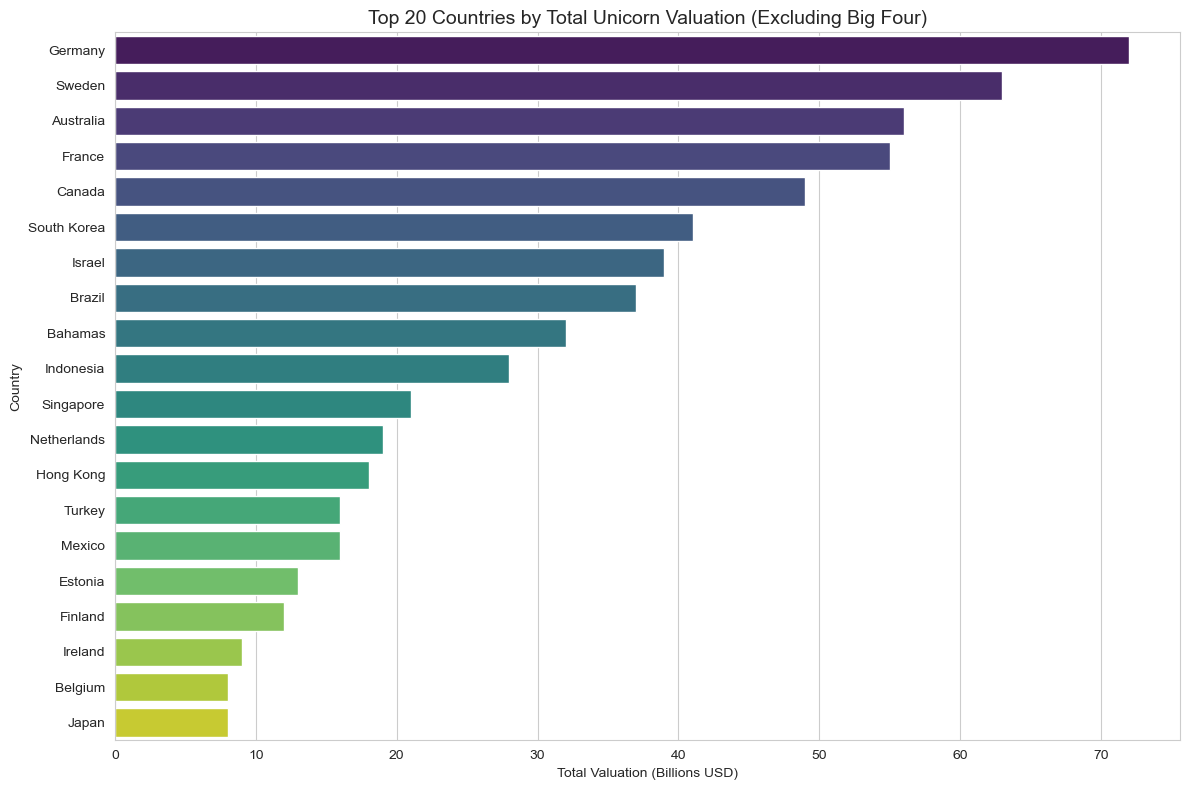

In [67]:
# Top 20 countries
top_20 = national_valuations_no_big4.head(20)

# Create the barplot
plt.figure(figsize=(12, 8))
sns.barplot(data=top_20, x='valuation_num', y='Country', palette='viridis')
plt.title('Top 20 Countries by Total Unicorn Valuation (Excluding Big Four)', fontsize=14)
plt.xlabel('Total Valuation (Billions USD)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

### Global Valuation Map
Use `plotly.express.scatter_geo()` to map total valuations per country.

In [69]:
# Create the map
fig = px.scatter_geo(
    national_valuations_no_big4,
    locations='Country',
    locationmode='country names',
    size='valuation_num',
    hover_name='Country',
    color='valuation_num',
    color_continuous_scale='Viridis',
    title='Global Unicorn Valuation Map (Excluding Big Four)',
    projection='natural earth'
)

fig.show()

### Europe-Focused Map
A separate map focusing on Europe for better detail.

In [70]:
# Filter for European countries
european_countries = [
    'Germany', 'France', 'Sweden', 'Netherlands', 'Switzerland',
    'Spain', 'Ireland', 'Belgium', 'Norway', 'Denmark',
    'Finland', 'Italy', 'Austria', 'Poland', 'Portugal',
    'Czech Republic', 'Estonia', 'Luxembourg', 'Iceland'
]

df_europe = national_valuations_no_big4[
    national_valuations_no_big4['Country'].isin(european_countries)
]

# Create Europe map
fig_europe = px.scatter_geo(
    df_europe,
    locations='Country',
    locationmode='country names',
    size='valuation_num',
    hover_name='Country',
    color='valuation_num',
    color_continuous_scale='Plasma',
    title='Unicorn Valuations in Europe',
    scope='europe'
)

fig_europe.show()

## Conclusion

### Key Takeaways
- Missing data was concentrated in the `Country/Region` column.
- Dropping rows was more efficient than dropping columns.
- Backfilling did not produce meaningful values.
- The top non-big-four countries by unicorn valuation are [top countries].
- Europe shows significant unicorn activity, especially in Germany, France, and Sweden.

### Next Steps
- Investigate why certain regions have missing data.
- Consider using more advanced imputation methods.
- Expand the analysis to include industry trends over time.